In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df=pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


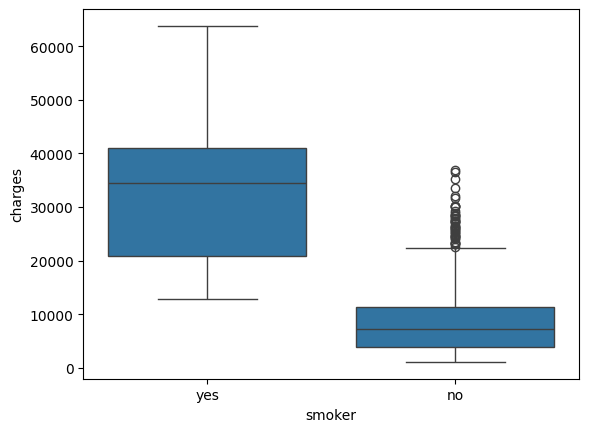

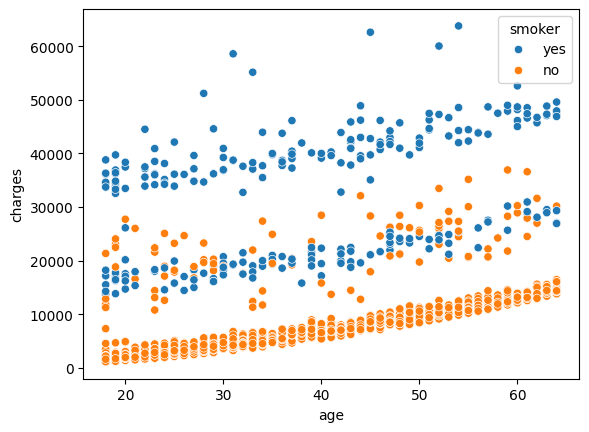

In [3]:
sns.boxplot(x="smoker",y="charges",data=df)
plt.show()
sns.scatterplot(x="age",y="charges",hue="smoker",data=df)
plt.show()

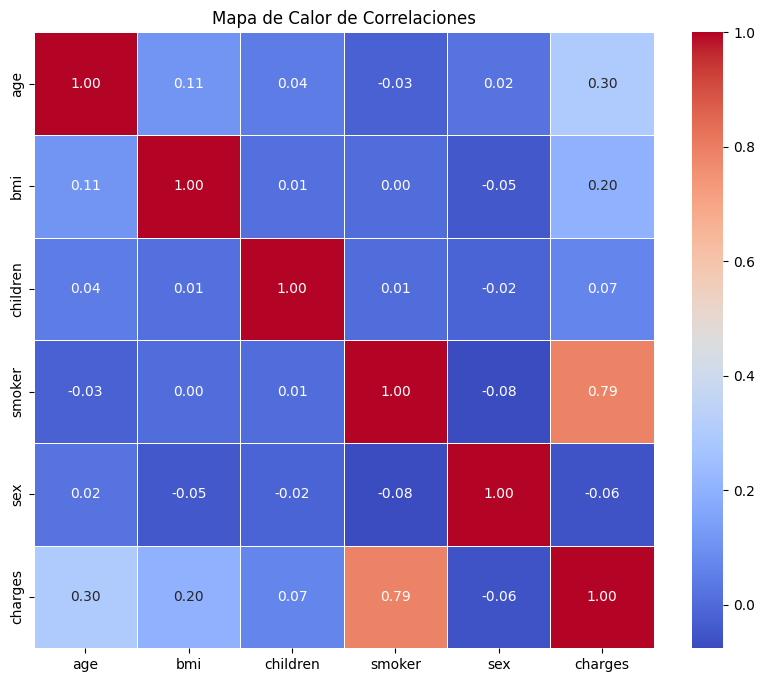

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Convertimos las variables de texto a números (Encoding)
# Esto es necesario para que el heatmap pueda calcular la correlación
df_numeric = df.copy()
df_numeric['smoker'] = df_numeric['smoker'].map({'yes': 1, 'no': 0})
df_numeric['sex'] = df_numeric['sex'].map({'female': 1, 'male': 0})
# Para la región, como son 4, podemos usar números del 0 al 3 o saltárnosla por ahora
df_numeric['region_n'] = pd.factorize(df_numeric['region'])[0]

# 2. Calculamos la matriz de correlación
corr_matrix = df_numeric[['age', 'bmi', 'children', 'smoker', 'sex', 'charges']].corr()

# 3. Dibujamos el Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Mapa de Calor de Correlaciones')
plt.show()

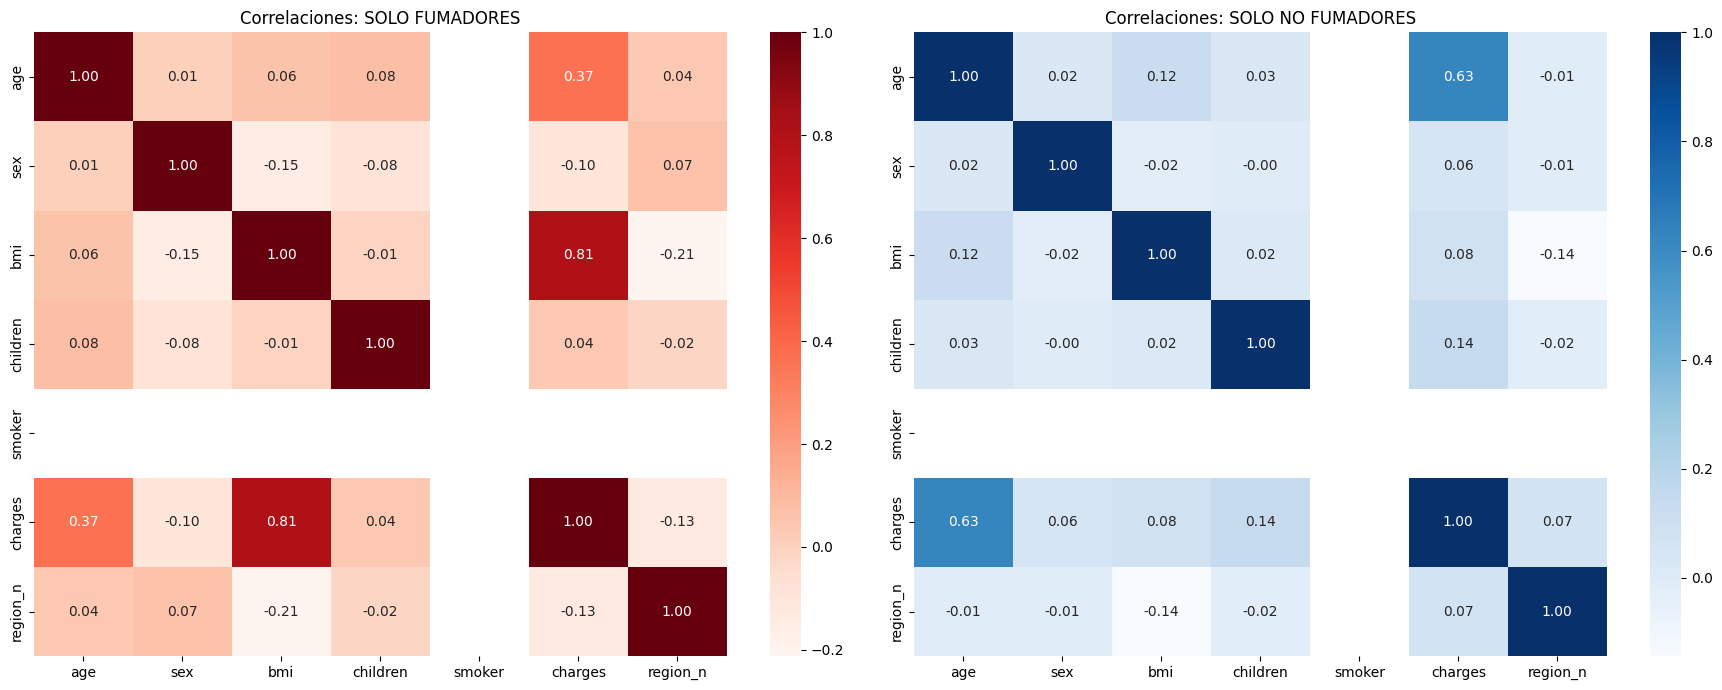

In [5]:
def plot_segmented_heatmaps(df):
    # 1. Aseguramos que los filtros funcionan y creamos copias
    smokers = df[df['smoker'] == 1].copy()
    non_smokers = df[df['smoker'] == 0].copy()
    
    # 2. Seleccionamos solo las columnas numéricas para cada grupo
    # Esto evita que Pandas se confunda con columnas de texto
    smokers_numeric = smokers.select_dtypes(include=[np.number])
    non_smokers_numeric = non_smokers.select_dtypes(include=[np.number])
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    
    # Heatmap para Fumadores
    sns.heatmap(smokers_numeric.corr(), 
                annot=True, cmap='Reds', fmt=".2f", ax=axes[0])
    axes[0].set_title('Correlaciones: SOLO FUMADORES')
    
    # Heatmap para No Fumadores
    sns.heatmap(non_smokers_numeric.corr(), 
                annot=True, cmap='Blues', fmt=".2f", ax=axes[1])
    axes[1].set_title('Correlaciones: SOLO NO FUMADORES')
    
    plt.tight_layout()
    plt.show()

# Importante: Usa el dataframe donde ya convertiste 'smoker' a 1 y 0
plot_segmented_heatmaps(df_numeric)

In [6]:
# Seleccionamos las columnas que tus heatmaps confirmaron como útiles
features = ['age', 'bmi', 'smoker', 'children']
X = df_numeric[features].values
y = df_numeric['charges'].values.reshape(-1, 1) # Lo ponemos en columna

In [7]:
from sklearn.model_selection import train_test_split

# random_state=42 es para que siempre te salgan los mismos datos (reproducibilidad)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
from sklearn.preprocessing import StandardScaler

scaler_x = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_x.fit_transform(X_train)
X_test_scaled = scaler_x.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

In [9]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train_scaled, dtype=torch.float32).to(device)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_test_scaled, dtype=torch.float32).to(device)

In [10]:
import torch.nn as nn
import torch.nn.functional as F

class InsuranceModel(nn.Module):
    def __init__(self, input_size):
        super(InsuranceModel, self).__init__()
        # Capa de entrada (4 variables) a 64 neuronas
        self.fc1 = nn.Linear(input_size, 64)
        # Capas ocultas para capturar la complejidad que vimos en el EDA
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 16)
        # Capa de salida (1 sola neurona: el coste)
        self.output = nn.Linear(16, 1)
        
    def forward(self, x):
        # ReLU es vital para que la red sea "inteligente" y no una simple línea
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        return self.output(x)

# Instanciamos el modelo y lo pasamos a la CPU/GPU
model = InsuranceModel(X_train_t.shape[1]).to(device)
print(model)

InsuranceModel(
  (fc1): Linear(in_features=4, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=16, bias=True)
  (output): Linear(in_features=16, out_features=1, bias=True)
)


In [11]:
import torch.optim as optim

# El criterio es el MAE (Mean Absolute Error)
criterion = nn.L1Loss() 

# El optimizador Adam ajusta los pesos de la red automáticamente
optimizer = optim.Adam(model.parameters(), lr=0.01) # Velocidad de aprendizaje

Época [20/200], MAE (escalado): 0.2508
Época [40/200], MAE (escalado): 0.1819
Época [60/200], MAE (escalado): 0.1627
Época [80/200], MAE (escalado): 0.1458
Época [100/200], MAE (escalado): 0.1467
Época [120/200], MAE (escalado): 0.1533
Época [140/200], MAE (escalado): 0.1353
Época [160/200], MAE (escalado): 0.1347
Época [180/200], MAE (escalado): 0.1411
Época [200/200], MAE (escalado): 0.1340


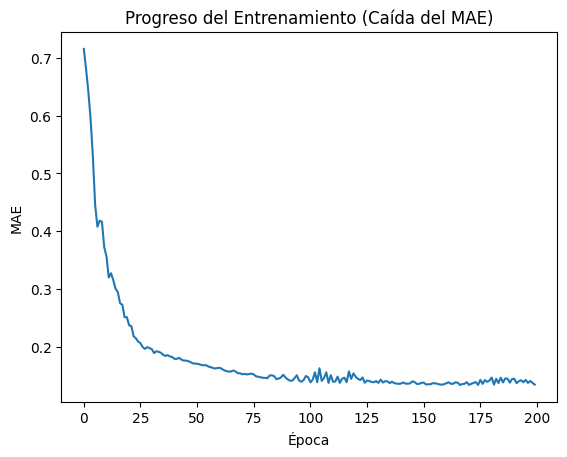

In [12]:
epochs = 200
history = []

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad() # Limpiamos gradientes anteriores
    
    # 1. Predicción (Forward pass)
    outputs = model(X_train_t)
    
    # 2. Cálculo del error (Loss)
    loss = criterion(outputs, y_train_t)
    
    # 3. Aprendizaje (Backpropagation)
    loss.backward()
    optimizer.step()
    
    history.append(loss.item())
    
    if (epoch + 1) % 20 == 0:
        print(f'Época [{epoch+1}/{epochs}], MAE (escalado): {loss.item():.4f}')

# Graficamos la curva de aprendizaje
plt.plot(history)
plt.title('Progreso del Entrenamiento (Caída del MAE)')
plt.xlabel('Época')
plt.ylabel('MAE')
plt.show()

In [13]:
model.eval()
with torch.no_grad():
    # Predecimos sobre el conjunto de TEST (el que la red nunca vio)
    test_preds_scaled = model(X_test_t)
    
    # Des-escalamos para volver a euros reales
    test_preds = scaler_y.inverse_transform(test_preds_scaled.cpu().numpy())
    y_actual = scaler_y.inverse_transform(y_test_t.cpu().numpy())
    
    # Calculamos el MAE final en euros
    final_mae = np.mean(np.abs(test_preds - y_actual))
    print(f"--- RESULTADO FINAL ---")
    print(f"El error medio de mi red es de: {final_mae:.2f} €")

--- RESULTADO FINAL ---
El error medio de mi red es de: 1563.03 €


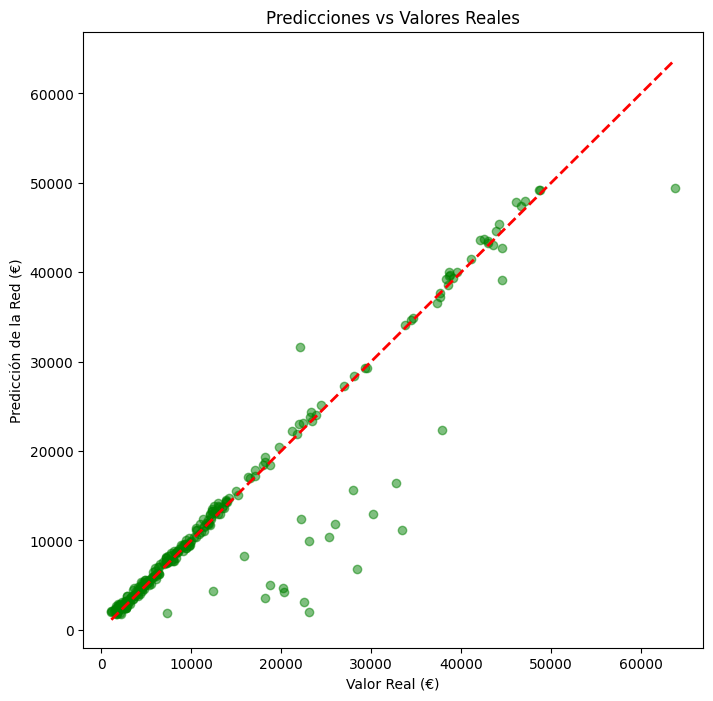

In [14]:
plt.figure(figsize=(8, 8))
plt.scatter(y_actual, test_preds, alpha=0.5, color='green')
plt.plot([y_actual.min(), y_actual.max()], [y_actual.min(), y_actual.max()], 'r--', lw=2)
plt.xlabel('Valor Real (€)')
plt.ylabel('Predicción de la Red (€)')
plt.title('Predicciones vs Valores Reales')
plt.show()

In [15]:
from sklearn.metrics import r2_score

# Calculamos el R2 comparando la realidad vs tu predicción
r2 = r2_score(y_actual, test_preds)

print(f"Puntuación R2: {r2:.4f}")

Puntuación R2: 0.8824


In [16]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Creamos el modelo (con 100 árboles)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# 2. Entrenamos (esto es mucho más rápido que la red neuronal)
rf_model.fit(X_train, y_train.ravel())

# 3. Predecimos sobre el mismo test que la red
rf_preds = rf_model.predict(X_test)

# 4. Calculamos métricas
mae_rf = mean_absolute_error(y_test, rf_preds)
r2_rf = r2_score(y_test, rf_preds)

print(f"--- RESULTADOS RANDOM FOREST ---")
print(f"MAE: {mae_rf:.2f} €")
print(f"R2: {r2_rf:.4f}")

--- RESULTADOS RANDOM FOREST ---
MAE: 2517.34 €
R2: 0.8592


In [18]:
import torch
from sklearn.preprocessing import StandardScaler

# Convertimos tus datos de Sklearn/Pandas a tensores de PyTorch
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values if hasattr(y_train, 'values') else y_train, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test.values if hasattr(y_test, 'values') else y_test, dtype=torch.float32).view(-1, 1)

print("Datos listos: X_train_tensor definido.")

Datos listos: X_train_tensor definido.


In [19]:
import optuna
import torch.nn as nn
import torch.optim as optim

def objective(trial):
    # 1. Sugerir Hiperparámetros
    n_layers = trial.suggest_int("n_layers", 1, 3)
    lr = trial.suggest_float("lr", 1e-4, 1e-1, log=True)
    
    layers = []
    in_features = X_train_tensor.shape[1]
    
    # Construcción dinámica de la red
    for i in range(n_layers):
        out_features = trial.suggest_int(f"n_units_l{i}", 16, 128)
        layers.append(nn.Linear(in_features, out_features))
        layers.append(nn.ReLU())
        # Añadimos Dropout para evitar que el modelo se aprenda los datos de memoria
        p = trial.suggest_float(f"dropout_l{i}", 0.1, 0.3)
        layers.append(nn.Dropout(p))
        in_features = out_features
        
    layers.append(nn.Linear(in_features, 1))
    model = nn.Sequential(*layers)
    
    # 2. Entrenamiento rápido para evaluación
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.L1Loss() # Maximizamos precisión en dólares (MAE)
    
    for epoch in range(100):
        model.train()
        optimizer.zero_grad()
        loss = criterion(model(X_train_tensor), y_train_tensor)
        loss.backward()
        optimizer.step()
        
    # 3. Validación
    model.eval()
    with torch.no_grad():
        preds = model(X_test_tensor)
        mae = mean_absolute_error(y_test_tensor.numpy(), preds.numpy())
    
    return mae

# Crear y ejecutar el estudio
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)

print(f"Mejor MAE encontrado: ${study.best_value:.2f}")
print(f"Mejores parámetros: {study.best_params}")

[I 2026-03-26 16:10:21,220] A new study created in memory with name: no-name-43091ccd-5447-4b2d-8894-7c358537254d
[I 2026-03-26 16:10:21,686] Trial 0 finished with value: 9726.44921875 and parameters: {'n_layers': 2, 'lr': 0.0062930289354427675, 'n_units_l0': 89, 'dropout_l0': 0.17453066398917383, 'n_units_l1': 62, 'dropout_l1': 0.16725557043320333}. Best is trial 0 with value: 9726.44921875.
[I 2026-03-26 16:10:21,883] Trial 1 finished with value: 12761.8330078125 and parameters: {'n_layers': 1, 'lr': 0.009989247745452299, 'n_units_l0': 83, 'dropout_l0': 0.17368399528227502}. Best is trial 0 with value: 9726.44921875.
[I 2026-03-26 16:10:22,031] Trial 2 finished with value: 12127.9091796875 and parameters: {'n_layers': 1, 'lr': 0.024694794962079672, 'n_units_l0': 53, 'dropout_l0': 0.14870694108544702}. Best is trial 0 with value: 9726.44921875.
[I 2026-03-26 16:10:22,505] Trial 3 finished with value: 12956.4443359375 and parameters: {'n_layers': 3, 'lr': 0.0003784488996621766, 'n_unit

Mejor MAE encontrado: $1979.72
Mejores parámetros: {'n_layers': 3, 'lr': 0.058941135286633625, 'n_units_l0': 38, 'dropout_l0': 0.11274999802159046, 'n_units_l1': 95, 'dropout_l1': 0.2746705697094654, 'n_units_l2': 84, 'dropout_l2': 0.2497788933824902}


In [20]:
import optuna
from optuna.pruners import MedianPruner

def objective(trial):
    # 1. Espacio de búsqueda más refinado
    n_layers = trial.suggest_int("n_layers", 2, 4) # Forzamos profundidad
    lr = trial.suggest_float("lr", 1e-3, 5e-2, log=True)
    
    layers = []
    in_features = X_train_tensor.shape[1]
    
    for i in range(n_layers):
        out_features = trial.suggest_int(f"n_units_l{i}", 32, 256) # Más neuronas
        layers.append(nn.Linear(in_features, out_features))
        layers.append(nn.ReLU())
        layers.append(nn.Dropout(0.15)) # Estabilidad
        in_features = out_features
        
    layers.append(nn.Linear(in_features, 1))
    model = nn.Sequential(*layers)
    
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.L1Loss() 

    # 2. Entrenamiento con PODA (Pruning)
    for epoch in range(500): # Subimos a 500 épocas
        model.train()
        optimizer.zero_grad()
        loss = criterion(model(X_train_tensor), y_train_tensor)
        loss.backward()
        optimizer.step()
        
        # Reportar progreso a Optuna para que pueda podar si es un mal trial
        trial.report(loss.item(), epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    model.eval()
    with torch.no_grad():
        preds = model(X_test_tensor)
        mae = mean_absolute_error(y_test_tensor.numpy(), preds.numpy())
    return mae

# Ejecutamos con un podador inteligente
study = optuna.create_study(direction="minimize", pruner=MedianPruner())
study.optimize(objective, n_trials=100) # 100 intentos ahora que somos rápidos

print(f"Mejor MAE tras optimización: ${study.best_value:.2f}")

[I 2026-03-26 16:12:07,420] A new study created in memory with name: no-name-6bc801e5-ac70-4b46-a509-4872d17e68ef
[I 2026-03-26 16:12:11,293] Trial 0 finished with value: 2009.4195556640625 and parameters: {'n_layers': 3, 'lr': 0.002744361311607026, 'n_units_l0': 62, 'n_units_l1': 109, 'n_units_l2': 122}. Best is trial 0 with value: 2009.4195556640625.
[I 2026-03-26 16:12:15,811] Trial 1 finished with value: 1497.5526123046875 and parameters: {'n_layers': 3, 'lr': 0.033373162643266625, 'n_units_l0': 43, 'n_units_l1': 109, 'n_units_l2': 249}. Best is trial 1 with value: 1497.5526123046875.
[I 2026-03-26 16:12:18,740] Trial 2 finished with value: 1914.83984375 and parameters: {'n_layers': 2, 'lr': 0.01848673173851784, 'n_units_l0': 139, 'n_units_l1': 115}. Best is trial 1 with value: 1497.5526123046875.
[I 2026-03-26 16:12:23,737] Trial 3 finished with value: 1675.9176025390625 and parameters: {'n_layers': 3, 'lr': 0.01048885365296129, 'n_units_l0': 221, 'n_units_l1': 104, 'n_units_l2': 

Mejor MAE tras optimización: $1497.55


In [21]:
# 1. Extraemos los mejores parámetros encontrados
best_params = study.best_params
n_layers = best_params['n_layers']
lr = best_params['lr']

# 2. Reconstruimos la arquitectura ganadora
layers = []
in_features = X_train_tensor.shape[1]
for i in range(n_layers):
    out_features = best_params[f"n_units_l{i}"]
    layers.append(nn.Linear(in_features, out_features))
    layers.append(nn.ReLU())
    layers.append(nn.Dropout(0.1)) # Un poco de relax para generalizar mejor
    in_features = out_features

layers.append(nn.Linear(in_features, 1))
final_model = nn.Sequential(*layers)

# 3. Entrenamiento de ALTA PRECISIÓN (2000 épocas)
optimizer = optim.Adam(final_model.parameters(), lr=lr)
criterion = nn.L1Loss()
history = []

print(f"Entrenando el modelo definitivo con {n_layers} capas...")

for epoch in range(2000):
    final_model.train()
    optimizer.zero_grad()
    outputs = final_model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()
    history.append(loss.item())
    
    if epoch % 200 == 0:
        print(f"Época {epoch}: MAE actual = ${loss.item():.2f}")

# 4. Resultado Final
final_model.eval()
with torch.no_grad():
    final_preds = final_model(X_test_tensor).numpy()
    real_mae = mean_absolute_error(y_test_tensor.numpy(), final_preds)
    real_r2 = r2_score(y_test_tensor.numpy(), final_preds)

print(f"\n🚀 RÉCORD REVENTADO 🚀")
print(f"MAE Final: ${real_mae:.2f}")
print(f"R² Final: {real_r2:.4f}")

Entrenando el modelo definitivo con 3 capas...
Época 0: MAE actual = $13345.98
Época 200: MAE actual = $2455.97
Época 400: MAE actual = $2433.98
Época 600: MAE actual = $2387.96
Época 800: MAE actual = $2353.28
Época 1000: MAE actual = $2355.70
Época 1200: MAE actual = $2392.78
Época 1400: MAE actual = $2470.92
Época 1600: MAE actual = $2293.61
Época 1800: MAE actual = $2412.87

🚀 RÉCORD REVENTADO 🚀
MAE Final: $2113.83
R² Final: 0.8514


In [22]:
import torch.optim.lr_scheduler as lr_scheduler

# 1. Arquitectura limpia y robusta
final_model = nn.Sequential(
    nn.Linear(X_train_tensor.shape[1], 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 1)
)

# 2. El truco: Bajar el LR a 0.01 y usar un Scheduler
optimizer = optim.Adam(final_model.parameters(), lr=0.01) 
scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=50, factor=0.5)
criterion = nn.L1Loss()
history = []

print("Entrenando con Reducción Automática de Learning Rate...")

for epoch in range(2500): # Le damos más tiempo pero más despacio
    final_model.train()
    optimizer.zero_grad()
    outputs = final_model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()
    
    # El scheduler mira si el error se estanca y baja el LR a la mitad
    scheduler.step(loss)
    history.append(loss.item())
    
    if epoch % 250 == 0:
        curr_lr = optimizer.param_groups[0]['lr']
        print(f"Época {epoch}: MAE = ${loss.item():.2f} | LR actual = {curr_lr}")

# 3. Evaluación final
final_model.eval()
with torch.no_grad():
    final_preds = final_model(X_test_tensor).numpy()
    real_mae = mean_absolute_error(y_test_tensor.numpy(), final_preds)
    real_r2 = r2_score(y_test_tensor.numpy(), final_preds)

print(f"\n✅ AHORA SÍ ✅")
print(f"MAE Final: ${real_mae:.2f}")
print(f"R² Final: {real_r2:.4f}")

Entrenando con Reducción Automática de Learning Rate...
Época 0: MAE = $13346.23 | LR actual = 0.01


c:\Users\Jon\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\optim\lr_scheduler.py:1694: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  current = float(metrics)


Época 250: MAE = $2213.14 | LR actual = 0.01
Época 500: MAE = $1911.09 | LR actual = 0.01
Época 750: MAE = $1730.29 | LR actual = 0.01
Época 1000: MAE = $1673.86 | LR actual = 0.01
Época 1250: MAE = $1676.72 | LR actual = 0.01
Época 1500: MAE = $1642.02 | LR actual = 0.01
Época 1750: MAE = $1626.17 | LR actual = 0.005
Época 2000: MAE = $1621.30 | LR actual = 0.0025
Época 2250: MAE = $1619.59 | LR actual = 0.0025

✅ AHORA SÍ ✅
MAE Final: $1494.32
R² Final: 0.8786
